In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"font.family": "serif",
                     "font.serif": ["Times New Roman"],
                     "font.size": 10,
                     "lines.linewidth": 1})
import pandas as pd
import os
from scipy.optimize import fsolve
ROOT = os.getcwd()
OUTPUT = os.path.join(ROOT, 'output')
FIGURES = os.path.join(ROOT, 'figures')
for _p in (
    os.path.join(OUTPUT, 'Bifurcations'),
    os.path.join(OUTPUT, 'trajectories_flow'),
    os.path.join(OUTPUT, 'score'),
    os.path.join(OUTPUT, 'score_trajectories'),
    os.path.join(FIGURES, 'Paper'),
):
    os.makedirs(_p, exist_ok=True)



# Functions

In [2]:
def N_fM(N_f, A_M, e):
    gamma = 1 / (1 + np.exp(-e))
    return ((A_M + N_f)*(1-gamma) + gamma- 
            np.sqrt(-4 * A_M * N_f * (1 - gamma) 
                    + ((A_M + N_f)*(1- gamma) + gamma)**2)) / (2 * (1 - gamma))

def N_dM(N_f, N_d, A_M, e):
    gamma = 1 / (1 + np.exp(-e))
    return (-A_M * N_d + (A_M * N_d) / (2 * (1 - gamma)) + (N_f * N_d) / (2 * (1 - gamma))
            + (N_d * gamma) / (2 * (1 - gamma)) - (A_M * N_d * gamma) / (2 * (1 - gamma)) - (N_f * N_d * gamma) / (2 * (1 - gamma))
            - (N_d * np.sqrt(-4 * A_M * N_f * (1 - gamma) + (A_M + N_f + gamma - A_M * gamma - N_f * gamma)**2)) / (2 * (1 - gamma)))/(N_f-1)

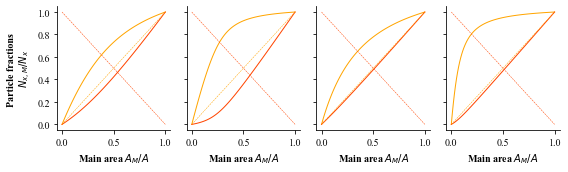

In [7]:
A_M_vals = np.linspace(0, 1, 100)

fig, axes = plt.subplots(1, 4, figsize=(8, 2.5), sharey=True)

# === Plot 1 ===
Nf, Nd, epsilon = 0.25, 0.25, -1
ax = axes[0]
ax.plot(A_M_vals, N_fM(Nf, A_M_vals, epsilon)/Nf, color = 'orange', label=r'$N_{f,M}/N_f$')
ax.plot(A_M_vals, N_dM(Nf, Nd, A_M_vals, epsilon)/Nd, color ='orangered', label=r'$N_{d,V}/N_d$')

# === Plot 2 ===
epsilon = -3
ax = axes[1]
ax.plot(A_M_vals, N_fM(Nf, A_M_vals, epsilon)/Nf, color = 'orange')
ax.plot(A_M_vals, N_dM(Nf, Nd, A_M_vals, epsilon)/Nd, color ='orangered')

# === Plot 3 ===
Nf, Nd, epsilon = 0.05, 0.05, -1
ax = axes[2]
ax.plot(A_M_vals, N_fM(Nf, A_M_vals, epsilon)/Nf, color = 'orange')
ax.plot(A_M_vals, N_dM(Nf, Nd, A_M_vals, epsilon)/Nd, color ='orangered')

# === Plot 4 ===
epsilon = -3
ax = axes[3]
ax.plot(A_M_vals, N_fM(Nf, A_M_vals, epsilon)/Nf, color = 'orange')
ax.plot(A_M_vals, N_dM(Nf, Nd, A_M_vals, epsilon)/Nd, color ='orangered')

for ax in axes:
    ax.plot(A_M_vals, A_M_vals, color = 'orange', lw=0.5, linestyle = '--')
    ax.plot(A_M_vals, 1-A_M_vals, color = 'orangered', lw=0.5, linestyle = '--')
    ax.set_xlabel('Main area $A_M/A$', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Particle fractions \n'+r'$N_{x,M}/N_x$', fontweight='bold')

# === Final layout and export ===
fig.tight_layout()
plt.savefig(os.path.join(FIGURES, 'Paper', 'number_equilibrium_all.svg'), dpi=300)
plt.show()

In [4]:
# remove spines to the top and the right

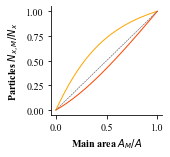

In [6]:
A_M_vals = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(2, 2), sharex=True, sharey=True)

# === Plot 1 ===
Nf, Nd, epsilon = 0.25, 0.25, -1
ax.plot(A_M_vals, N_fM(Nf, A_M_vals, epsilon)/Nf, color = 'orange', label=r'$N_{f,M}/N_f$')
ax.plot(A_M_vals, N_dM(Nf, Nd, A_M_vals, epsilon)/Nd, color = 'orangered', label=r'$N_{d,M}/N_d$')

ax.plot(A_M_vals, A_M_vals, color = 'grey', lw=0.5, linestyle = '--', label='No binding')
ax.plot(A_M_vals, A_M_vals, color = 'grey', lw=0.5, linestyle = '--')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel(r'Main area $A_M/A$', fontweight='bold')
ax.set_ylabel(r'Particles $N_{x,M}/N_x$', fontweight='bold')
plt.savefig(os.path.join(FIGURES, 'Paper', 'number_equilibrium.svg'), dpi=300)
plt.show()

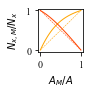

In [8]:
A_M_vals = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(0.8, 0.8), sharex=True, sharey=True)

# === Plot 1 ===
Nf, Nd, epsilon = 0.25, 0.25, -1
ax.plot(A_M_vals, N_fM(Nf, A_M_vals, epsilon)/Nf, color = 'orange', label=r'$N_{f,M}/N_f$')
ax.plot(A_M_vals, 1-N_dM(Nf, Nd, A_M_vals, epsilon)/Nd, color = 'orangered')

ax.plot(A_M_vals, A_M_vals, color = 'orange', lw=0.5, linestyle = '--')
ax.plot(A_M_vals, 1-A_M_vals, color = 'orangered', lw=0.5, linestyle = '--')

ax.set_xlabel(r'$A_M/A$', fontweight='bold')
ax.set_ylabel(r'$N_{x,M}/N_x$', fontweight='bold')
plt.savefig(os.path.join(FIGURES, 'Paper', 'number_equilibrium_inset.svg'), dpi=300)
plt.show()